In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, norm
from statsmodels.distributions.empirical_distribution import ECDF

## Import and Inspection of Data

In [4]:
# === 1. Load Required CSVs ===
# Paths are based on your current directory structure
copula_pairs = pd.read_csv("copula_pairs.csv")
price_data = pd.read_csv("sp500_prices_cleaned.csv", index_col=0, parse_dates=True)

# === 2. Inspect Loaded Data ===
print("Pairs loaded:", len(copula_pairs))
print("Price data shape:", price_data.shape)
print(copula_pairs.head())
print(price_data.iloc[:, :5].head())  # Show first 5 tickers

# === 3. Preprocess: Ensure consistent tickers in price data ===
tickers_needed = pd.unique(copula_pairs[["Stock A", "Stock B"]].values.ravel())
missing_tickers = [t for t in tickers_needed if t not in price_data.columns]

if missing_tickers:
    print("❌ Missing tickers in price data:", missing_tickers)
else:
    print("✅ All tickers for copula strategy present in price data.")

Pairs loaded: 11
Price data shape: (752, 497)
  Stock A Stock B
0      MA       V
1     FRT     KIM
2     MCO    SPGI
3     AVB     ESS
4     DHI     LEN
                                  MMM        AOS         ABT        ABBV  \
Date                                                                       
2022-01-03 00:00:00-05:00  128.667679  78.466614  130.151352  118.637070   
2022-01-04 00:00:00-05:00  130.470215  79.771706  127.090416  118.409309   
2022-01-05 00:00:00-05:00  129.934525  78.438446  126.519440  119.031311   
2022-01-06 00:00:00-05:00  128.855911  78.964233  126.500679  118.470604   
2022-01-07 00:00:00-05:00  130.267548  78.072243  126.893814  118.163994   

                                  ACN  
Date                                   
2022-01-03 00:00:00-05:00  385.631042  
2022-01-04 00:00:00-05:00  382.875244  
2022-01-05 00:00:00-05:00  376.132477  
2022-01-06 00:00:00-05:00  357.968903  
2022-01-07 00:00:00-05:00  351.103088  
✅ All tickers for copula strategy

## Calculate Log Returns

In [8]:
log_returns = np.log(price_data / price_data.shift(1)).dropna()
print("Log returns shape:", log_returns.shape)
display(log_returns.iloc[:, :5].head())

Log returns shape: (751, 497)


,MMM,AOS,ABT,ABBV,ACN
Date,,,,,
2022-01-04 00:00:00-05:00,0.013912,0.016496,-0.023799,-0.001922,-0.007172
2022-01-05 00:00:00-05:00,-0.004114,-0.016855,-0.004503,0.005239,-0.017768
2022-01-06 00:00:00-05:00,-0.008336,0.006681,-0.000148,-0.004722,-0.049495
2022-01-07 00:00:00-05:00,0.010896,-0.011360,0.003103,-0.002591,-0.019366
2022-01-10 00:00:00-05:00,-0.014216,-0.003132,-0.002216,0.011133,0.006051


## Loop Through Pairs and Create ECDF-Transformed Marginals

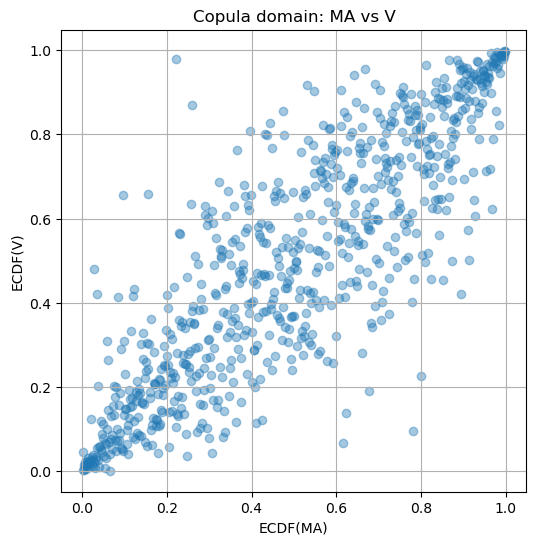

In [10]:
def ecdf_transform(series):
    """Transforms a series to its empirical CDF values (uniform [0,1])."""
    ranks = rankdata(series)
    return ranks / (len(series) + 1)

# Example: transform for first pair
example_pair = copula_pairs.iloc[0]
stock_a, stock_b = example_pair["Stock A"], example_pair["Stock B"]

# Align data
pair_data = log_returns[[stock_a, stock_b]].dropna()

# Apply ECDF transformation
u = ecdf_transform(pair_data[stock_a])
v = ecdf_transform(pair_data[stock_b])

# Scatter plot of transformed marginals (Copula domain)
plt.figure(figsize=(6, 6))
plt.scatter(u, v, alpha=0.4)
plt.xlabel(f"ECDF({stock_a})")
plt.ylabel(f"ECDF({stock_b})")
plt.title(f"Copula domain: {stock_a} vs {stock_b}")
plt.grid(True)
plt.show()

## Gaussian Copula

Estimated Gaussian copula correlation: 0.8653


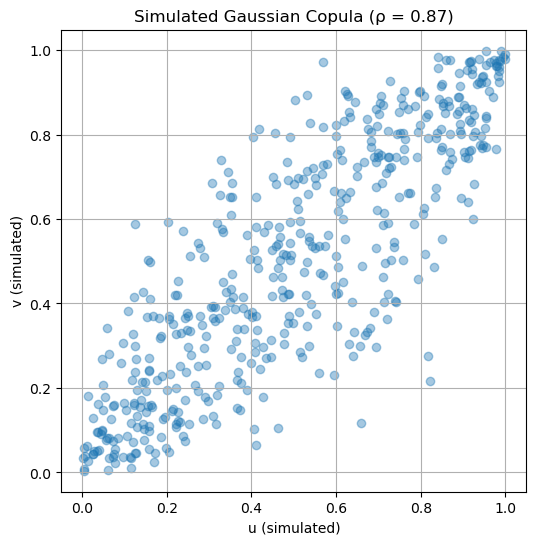

In [13]:
from scipy.stats import norm
from scipy.stats import multivariate_normal

# Convert ECDF marginals to standard normal quantiles
z_u = norm.ppf(u)
z_v = norm.ppf(v)

# Estimate the correlation between the transformed marginals
copula_corr = np.corrcoef(z_u, z_v)[0, 1]
print(f"Estimated Gaussian copula correlation: {copula_corr:.4f}")

# Optional: visualize the Gaussian copula sample
copula_sample = multivariate_normal.rvs(mean=[0, 0],
                                        cov=[[1, copula_corr], [copula_corr, 1]],
                                        size=500)

plt.figure(figsize=(6, 6))
plt.scatter(norm.cdf(copula_sample[:, 0]), norm.cdf(copula_sample[:, 1]), alpha=0.4)
plt.title(f"Simulated Gaussian Copula (ρ = {copula_corr:.2f})")
plt.xlabel("u (simulated)")
plt.ylabel("v (simulated)")
plt.grid(True)
plt.show()

## t-Copula for one pair (MA - V)

✅ Estimated t-copula parameters:
   - Correlation (ρ): 0.8485
   - Degrees of freedom (ν): 5.00


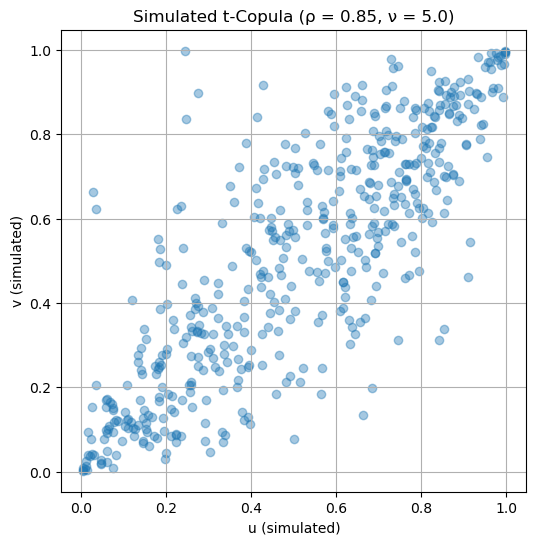

In [18]:
from scipy.stats import t, rankdata
from scipy.optimize import minimize
from scipy.stats import multivariate_t
import warnings

warnings.filterwarnings("ignore")

# === Step 1: Convert ECDF-transformed margins to inverse t-distribution quantiles ===
def inverse_t_transform(u, df):
    return t.ppf(u, df)

# === Step 2: Negative log-likelihood for t-copula ===
def t_copula_negloglik(params, u, v):
    rho, df = params
    if not (-0.99 < rho < 0.99 and df > 2):
        return np.inf

    x = inverse_t_transform(u, df)
    y = inverse_t_transform(v, df)
    z = np.vstack((x, y)).T

    cov = [[1, rho], [rho, 1]]
    det = 1 - rho**2

    t_log_pdf = (
        np.log(np.exp(t.logpdf(x, df)) * np.exp(t.logpdf(y, df))) -
        0.5 * (df + 2) * np.log(1 + (x**2 + y**2 - 2*rho*x*y)/ (df * det)) +
        0.5 * np.log(det)
    )

    return -np.sum(t_log_pdf)

# === Step 3: Fit via optimization ===
initial_params = [np.corrcoef(u, v)[0, 1], 5]
bounds = [(-0.99, 0.99), (2.01, 30)]

result = minimize(t_copula_negloglik, initial_params, args=(u, v), bounds=bounds)

rho_hat, df_hat = result.x
print(f"✅ Estimated t-copula parameters:\n   - Correlation (ρ): {rho_hat:.4f}\n   - Degrees of freedom (ν): {df_hat:.2f}")

# Simulate from fitted t-copula
copula_sample_t = multivariate_t.rvs(loc=[0, 0], shape=[[1, rho_hat], [rho_hat, 1]], df=df_hat, size=500)

# Transform back to ECDF space
u_sim = t.cdf(copula_sample_t[:, 0], df=df_hat)
v_sim = t.cdf(copula_sample_t[:, 1], df=df_hat)

# Plot simulated ECDF-marginals from t-Copula
plt.figure(figsize=(6, 6))
plt.scatter(u_sim, v_sim, alpha=0.4)
plt.title(f"Simulated t-Copula (ρ = {rho_hat:.2f}, ν = {df_hat:.1f})")
plt.xlabel("u (simulated)")
plt.ylabel("v (simulated)")
plt.grid(True)
plt.show()

## t-Copula for all pairs

In [21]:
from scipy.stats import t, rankdata
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

# Helper: ECDF transformation
def ecdf_transform(series):
    ranks = rankdata(series)
    return ranks / (len(series) + 1)

# Helper: Inverse t-transform
def inverse_t_transform(u, df):
    return t.ppf(u, df)

# Helper: Negative log-likelihood for t-Copula
def t_copula_negloglik(params, u, v):
    rho, df = params
    if not (-0.99 < rho < 0.99 and df > 2):
        return np.inf

    x = inverse_t_transform(u, df)
    y = inverse_t_transform(v, df)
    z = np.vstack((x, y)).T

    det = 1 - rho**2
    cov = [[1, rho], [rho, 1]]

    x2 = x**2
    y2 = y**2
    xy = 2 * rho * x * y

    log_pdf = (
        np.log(np.exp(t.logpdf(x, df)) * np.exp(t.logpdf(y, df))) -
        0.5 * (df + 2) * np.log(1 + (x2 + y2 - xy) / (df * det)) +
        0.5 * np.log(det)
    )
    return -np.sum(log_pdf)

# === Loop through all 11 pairs ===
copula_results = []

for _, row in copula_pairs.iterrows():
    stock_a, stock_b = row["Stock A"], row["Stock B"]
    pair_data = log_returns[[stock_a, stock_b]].dropna()
    u = ecdf_transform(pair_data[stock_a])
    v = ecdf_transform(pair_data[stock_b])

    # Initial guess and bounds
    init_params = [np.corrcoef(u, v)[0, 1], 5]
    bounds = [(-0.99, 0.99), (2.01, 30)]

    result = minimize(t_copula_negloglik, init_params, args=(u, v), bounds=bounds)
    rho_hat, df_hat = result.x

    copula_results.append({
        "Stock A": stock_a,
        "Stock B": stock_b,
        "t-Copula ρ": rho_hat,
        "t-Copula ν": df_hat,
        "Log-Likelihood": -result.fun
    })

# Convert to DataFrame
copula_df = pd.DataFrame(copula_results)

# Export
copula_df.to_csv("t_copula_params.csv", index=False)
print("✅ Exported t-copula parameters for all 11 pairs to 't_copula_params.csv'")
display(copula_df)

✅ Exported t-copula parameters for all 11 pairs to 't_copula_params.csv'


,Stock A,Stock B,t-Copula ρ,t-Copula ν,Log-Likelihood
0,MA,V,0.848479,5.0,-3895.437307
1,FRT,KIM,0.871350,5.0,-3978.578323
2,MCO,SPGI,0.857499,5.0,-3935.623231
3,AVB,ESS,0.881004,5.0,-3987.302389
4,DHI,LEN,0.936654,5.0,-4230.268894
5,LEN,PHM,0.902053,5.0,-4050.058381
6,COP,EOG,0.859783,5.0,-3909.844059
7,CMS,DTE,0.853257,5.0,-3906.128926
8,AEE,WEC,0.861084,5.0,-3930.495991
9,ED,WEC,0.845573,5.0,-3917.713978


In [23]:
# Rank by copula correlation
ranked = copula_df.sort_values(by="t-Copula ρ", ascending=False).reset_index(drop=True)
display(ranked.head(5))  # Top 5 pairs

,Stock A,Stock B,t-Copula ρ,t-Copula ν,Log-Likelihood
0,DHI,LEN,0.936654,5.0,-4230.268894
1,LEN,PHM,0.902053,5.0,-4050.058381
2,AVB,ESS,0.881004,5.0,-3987.302389
3,FRT,KIM,0.871350,5.0,-3978.578323
4,AEE,WEC,0.861084,5.0,-3930.495991
